### 📝 Exercise-1: Implementing the Perceptron Algorithm on Linearly Separable Data **[20 points]**

#### **Goal**  
In this exercise, you will implement the **Perceptron learning algorithm** on a dataset generated from a **linearly separable logistic regression model**.

---

### **Instructions**

1. **Data Generation (Synthetic):**
   - Generate a dataset of **100 two-dimensional points** \( x \in \mathbb{R}^2 \) - 2 points.
   - Choose a **random weight vector** \( w^* \in \mathbb{R}^2 \) and **bias** \( b^* \) - 2 points.
   - Generate labels using the logistic model:  
     \[
     y = \text{sign}(\sigma(w^* \cdot x + b^*) - 0.5)
     \]
     where \( \sigma(z) = \frac{1}{1 + e^{-z}} \) is the sigmoid function. - 6 points
   - This will give you a **linearly separable dataset**. You may discard or regenerate any point where \( \sigma \approx 0.5 \) to enforce clean separation.

2. **Online Learning Setup:**
   - Shuffle the data and present it as an **online sequence** (one point at a time) - 5 points.
   - Initialize weights \( w = 0 \), bias \( b = 0 \) - 5 points.

3. **Implement the Perceptron Update Rule:**
   - For each incoming example \( (x_t, y_t) \), make a prediction:
     \[
     \hat{y}_t = \text{sign}(w \cdot x_t + b)
     \] - 10 points
   - If the prediction is incorrect, update using perceptron update rule. - 5 points

4. **Your Tasks:**
   - Implement the above algorithm in Python.
   - Print the final weights and bias after all 100 points. - 5 points
   - Visualize the data points and report the plot of the decision boundary after 10, 50, 100, 200, 500 iterations. - 5 points

---

### 🔍 **Bonus (Optional):**
- Try changing the order in which data is presented and observe whether it affects convergence. - 5 points

---


1. Data Generation (Synthetic):

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sign_label(v):
    return 1 if v >= 0 else -1

n_samples = 100
X = []
y = []

w_star = np.random.randn(2)
b_star = np.random.randn()

while len(X) < n_samples:
    x = np.random.uniform(-5, 5, size=2)
    prob = sigmoid(np.dot(w_star, x) + b_star)

    if abs(prob - 0.5) < 0.05:
        continue

    label = 1 if prob > 0.5 else -1
    X.append(x)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("True w* =", w_star)
print("True b* =", b_star)

True w* = [ 0.49671415 -0.1382643 ]
True b* = 0.6476885381006925


2. Online Learning Setup:

In [3]:
perm = np.random.permutation(n_samples)
X = X[perm]
y = y[perm]

3. Implement the Perceptron Update Rule:

In [4]:
w = np.zeros(2)
b = 0.0

snapshot_iters = [10, 50, 100, 200, 500]
snapshots = {}

total_iterations = 500

for t in range(1, total_iterations + 1):
    i = (t - 1) % n_samples
    x_t = X[i]
    y_t = y[i]
    y_hat = sign_label(np.dot(w, x_t) + b)

    if y_hat != y_t:
        w = w + y_t * x_t
        b = b + y_t

    if t in snapshot_iters:
        snapshots[t] = (w.copy(), b)

print("\nFinal weights after 500 iterations:")
print("w =", w)
print("b =", b)


Final weights after 500 iterations:
w = [ 4.90563193 -2.06111624]
b = 5.0


4. Visualization:

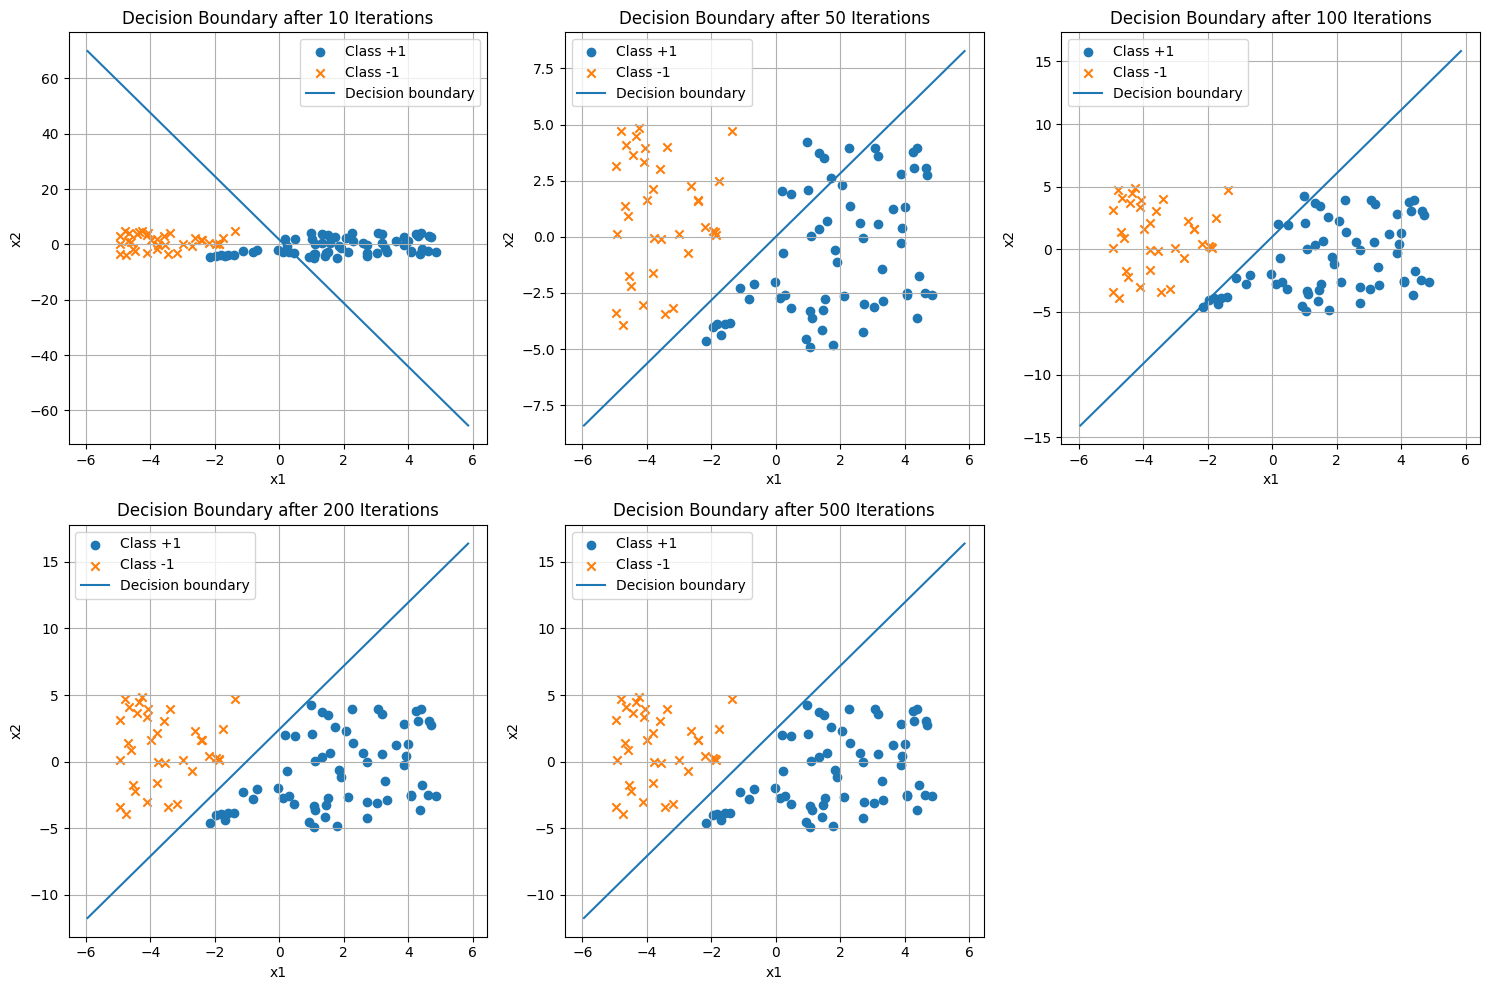

In [8]:
def plot_decision_boundary(ax, X, y, w, b, title):
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker='o', label='Class +1')
    ax.scatter(X[y == -1, 0], X[y == -1, 1], marker='x', label='Class -1')

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    xs = np.linspace(x_min, x_max, 200)

    if abs(w[1]) > 1e-8:
        ys = -(w[0] * xs + b) / w[1]
        ax.plot(xs, ys, label='Decision boundary')
    elif abs(w[0]) > 1e-8:
        x_line = -b / w[0]
        ax.axvline(x=x_line, label='Decision boundary')

    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, it in enumerate(snapshot_iters):
    w_snap, b_snap = snapshots[it]
    plot_decision_boundary(
        axes[idx], X, y, w_snap, b_snap,
        f"Decision Boundary after {it} Iterations"
    )

axes[-1].axis("off")

plt.tight_layout()
plt.show()

Bonus:

In [9]:
for trial in range(3):
    perm = np.random.permutation(n_samples)
    X_trial = X[perm]
    y_trial = y[perm]

    w = np.zeros(2)
    b = 0.0

    mistakes = 0
    for t in range(500):
        i = t % n_samples
        x_t = X_trial[i]
        y_t = y_trial[i]

        y_hat = 1 if np.dot(w, x_t) + b >= 0 else -1
        if y_hat != y_t:
            w += y_t * x_t
            b += y_t
            mistakes += 1

    print(f"Trial {trial+1}: mistakes = {mistakes}, w = {w}, b = {b}")

Trial 1: mistakes = 13, w = [ 6.03074954 -2.97785299], b = 9.0
Trial 2: mistakes = 14, w = [ 6.75114299 -1.41708835], b = 10.0
Trial 3: mistakes = 15, w = [10.16009961 -4.24445387], b = 9.0


The order in which the samples are presented does affect the perceptron learning algorithm. Different shuffles of the data resulted in a different amount of mistakes as well as different weight values. Since linearly separable data can often be separated with many different hyperplanes, the perceptron algorithm may converge on a different solution depending on the order the data is presented in.

# Exercise-2: Kernel Perceptron on Quadratically Separable Data **[20 points]**

**Objective:**  
Explore the limitations of linear classifiers and implement a kernelized perceptron to classify data that is not linearly separable but separable in a higher-order feature space using a kernel function.

---

## Q1: Dataset Generation – Quadratically Separable Data

**(a)** Generate a 2D dataset by sampling 100 data points from a standard 2D Gaussian distribution centered at the origin.  
*(Hint: use `np.random.randn(100, 2)`)* - 5 points

**(b)** Label the data using the following rule:  
  Assign class **+1** if $x_1^2 + x_2^2 > 1$, otherwise assign class **-1**. - 5 points

**(c)** Visualize the dataset - 10 points:  
- Plot the points using color to indicate class labels.  
- Optionally overlay the circular decision boundary ($x_1^2 + x_2^2 = 1$).  
- Include axis labels and a legend.

---

## Q2: Kernel Perceptron Implementation

**(a)** Implement the **kernelized perceptron** algorithm using a **polynomial kernel** - 5 points:  
  $K(x, x') = (\langle x, x' \rangle + 1)^d$, with $d = 2$

**(b)** Train the kernel perceptron on the dataset and predict on the training data. - 5 points

**(c)** Visualize the predicted classes. - 5 points

---

## Q3: Kernel Choice & Experiments (Optional)

**(a)** Try different values of the polynomial degree $d$ (e.g., 1, 2, 3, 5). How does the performance change? - 5 points

**(b)**  Replace the polynomial kernel with a **Gaussian RBF kernel** and re-run the experiment. - 5 points

**(c)** Compare and comment on the results with different kernels. -  5 points

---














1. Dataset Generation:

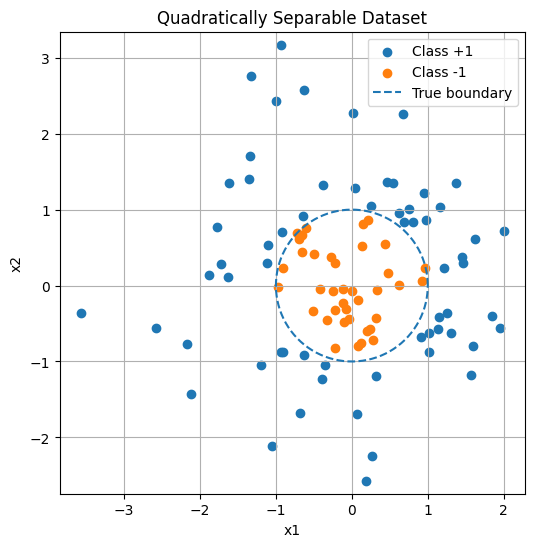

In [11]:
X = np.random.randn(100, 2)
y = np.where(X[:, 0]**2 + X[:, 1]**2 >= 1, 1, -1)

plt.figure(figsize=(6, 6))
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class +1')
plt.scatter(X[y == -1, 0], X[y == -1, 1], label='Class -1')

theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', label='True boundary')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Quadratically Separable Dataset")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

2. Kernel Perceptron Implementation:

Epoch 1: mistakes = 22
Epoch 2: mistakes = 9
Epoch 3: mistakes = 2
Epoch 4: mistakes = 5
Epoch 5: mistakes = 4
Epoch 6: mistakes = 0

Training accuracy: 1.0


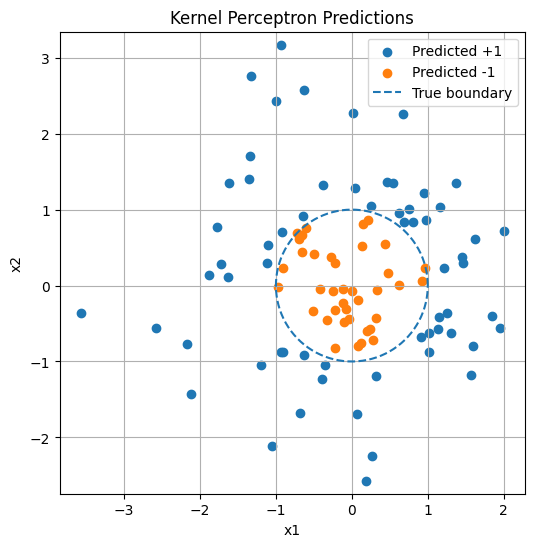

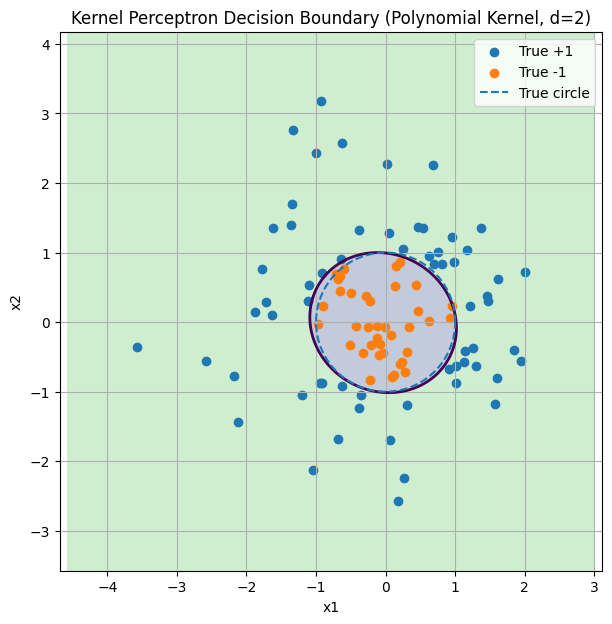

In [12]:
def polynomial_kernel(x, z, d=2):
    return (np.dot(x, z) + 1) ** d

def compute_kernel_matrix(X, d=2):
    n = X.shape[0]
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            K[i, j] = polynomial_kernel(X[i], X[j], d)
    return K

def kernel_perceptron_train(X, y, d=2, epochs=10):
    n = X.shape[0]
    alpha = np.zeros(n)
    K = compute_kernel_matrix(X, d=d)

    for epoch in range(epochs):
        mistakes = 0
        for i in range(n):
            score = np.sum(alpha * y * K[:, i])
            y_hat = 1 if score >= 0 else -1

            if y_hat != y[i]:
                alpha[i] += 1
                mistakes += 1

        print(f"Epoch {epoch+1}: mistakes = {mistakes}")
        if mistakes == 0:
            break

    return alpha, K

def kernel_perceptron_predict(X_train, y_train, alpha, X_test, d=2):
    preds = []
    for x in X_test:
        score = 0
        for i in range(len(X_train)):
            if alpha[i] > 0:
                score += alpha[i] * y_train[i] * polynomial_kernel(X_train[i], x, d)
        preds.append(1 if score >= 0 else -1)
    return np.array(preds)

alpha, K = kernel_perceptron_train(X, y, d=2, epochs=20)
y_pred = kernel_perceptron_predict(X, y, alpha, X, d=2)

accuracy = np.mean(y_pred == y)
print("\nTraining accuracy:", accuracy)

plt.figure(figsize=(6, 6))
plt.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], label='Predicted +1')
plt.scatter(X[y_pred == -1, 0], X[y_pred == -1, 1], label='Predicted -1')

plt.plot(np.cos(theta), np.sin(theta), linestyle='--', label='True boundary')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Kernel Perceptron Predictions")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

def decision_function(X_train, y_train, alpha, point, d=2):
    score = 0
    for i in range(len(X_train)):
        if alpha[i] > 0:
            score += alpha[i] * y_train[i] * polynomial_kernel(X_train[i], point, d)
    return score

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([decision_function(X, y, alpha, p, d=2) for p in grid_points])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 7))
plt.contourf(xx, yy, Z > 0, alpha=0.3)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

plt.scatter(X[y == 1, 0], X[y == 1, 1], label='True +1')
plt.scatter(X[y == -1, 0], X[y == -1, 1], label='True -1')
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', label='True circle')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Kernel Perceptron Decision Boundary (Polynomial Kernel, d=2)")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()